# Decision Tree
- A Decision Tree (from scikit-learn) is used because it is a simple and powerful machine learning algorithm that makes decisions based on feature rules, similar to human decision-making.

In [1]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path
PROJECT_ROOT= Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))
from src.preprocessing import load_data, build_preprocessor, split_data,extract_cat_col_num_cols

import matplotlib.pyplot as plt
import seaborn as sns
 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn import metrics


The configurations are successfully applied
The preprocessing step is completed


In [2]:
## Load data
df=load_data()
df.head()

,color,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,genres,num_voted_users,cast_total_facebook_likes,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,723.0,178.0,0.0,855.0,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,886204,4834,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,302.0,169.0,563.0,1000.0,40000.0,309404152.0,Action|Adventure|Fantasy,471220,48350,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,602.0,148.0,0.0,161.0,11000.0,200074175.0,Action|Adventure|Thriller,275868,11700,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,813.0,164.0,22000.0,23000.0,27000.0,448130642.0,Action|Thriller,1144337,106759,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,NaN,NaN,131.0,NaN,131.0,NaN,Documentary,8,143,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [3]:
df=df.copy()

In [4]:
## Meta data
print("No.of rows:",df.shape[0])
print("\n No.of columns:",df.shape[1])
print("\n All columns:",df.columns.to_list())
print ("\n Data-types:",df.dtypes)
print("\n Info:")
df.info()
print ("\n no.of Duplicates:",df.duplicated().sum())

No.of rows: 5043

 No.of columns: 21

 All columns: ['color', 'num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'genres', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

 Data-types: color                         object
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_1_facebook_likes       float64
gross                        float64
genres                        object
num_voted_users                int64
cast_total_facebook_likes      int64
facenumber_in_poster         float64
num_user_for_reviews         float64
language                      object
country                       object
content_rating               

In [5]:
## remove duplicates
df.drop_duplicates(inplace = True)
print("Count of Duplicates:",df.duplicated().sum())

Count of Duplicates: 0


In [6]:
## Null values
df.isnull().sum()

color                         19
num_critic_for_reviews        49
duration                      15
director_facebook_likes      103
actor_3_facebook_likes        23
actor_1_facebook_likes         7
gross                        874
genres                         0
num_voted_users                0
cast_total_facebook_likes      0
facenumber_in_poster          13
num_user_for_reviews          21
language                      14
country                        5
content_rating               301
budget                       487
title_year                   107
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 327
movie_facebook_likes           0
dtype: int64

In [7]:
def classify_movie(score):
    if score <= 3:
        return "Flop"
    elif score <= 6:
        return "Average"
    else:
        return "Hit"

df["Classify"] = df["imdb_score"].apply(classify_movie)

In [8]:
df['Classify'].isnull().sum()

np.int64(0)

In [9]:
# Seperate feature and target
X =df.drop(["Classify","imdb_score"],axis=1)     # features
y =df["Classify"]                     # target

In [10]:
# split data
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
preprocessor = build_preprocessor(X_train)

model = DecisionTreeClassifier()

pipe_dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [12]:
# Training
pipe_dt.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['color', 'genres',
                                                   'language', 'country',
                                                   'content_rating']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   Standa...
                                                  ['num_critic_for_reviews',
                                                   'duration',
                                                   'director_facebook_likes',
                                                   'actor_3_facebook_likes',
                                                   'actor_1_facebook_likes',
                                                   'gross', 'num_voted_users',
                                                   'cast_total_facebook_likes',
                                                   'facenumber_in_poster',
                                                   'num_user_for_reviews',
                                                   'budget', 'title_year',
                                                   'actor_2_facebook_likes',
                                                   'aspect_ratio',
                                                   'movie_facebook_likes'])],
                                   verbose_feature_names_out=False)),
                ('model', DecisionTreeClassifier())])

In [14]:
# prediction

y_pred = pipe_dt.predict(X_test)
df_pred = pd.DataFrame({"Actual":y_test, "Prediction":y_pred})
df_pred.head(10)

,Actual,Prediction
84,Average,Average
2485,Hit,Hit
2826,Hit,Hit
5031,Average,Hit
4968,Average,Hit
4759,Hit,Hit
158,Hit,Hit
713,Average,Hit
4700,Average,Hit
1190,Average,Hit


In [15]:
### model evaluation
accuracy = metrics.accuracy_score(y_test,y_pred)
conf = metrics.confusion_matrix(y_test,y_pred)
report= metrics.classification_report(y_test,y_pred)


print(f"Model Accuracy:{accuracy*100:.2f}%")
print ("\n Classification Report: \n",report)
print ("\n Confusion matrix:\n",conf)

Model Accuracy:72.90%

 Classification Report: 
               precision    recall  f1-score   support

     Average       0.56      0.56      0.56       304
        Flop       0.00      0.00      0.00         6
         Hit       0.81      0.81      0.81       690

    accuracy                           0.73      1000
   macro avg       0.46      0.46      0.46      1000
weighted avg       0.73      0.73      0.73      1000


 Confusion matrix:
 [[169   8 127]
 [  4   0   2]
 [129   1 560]]


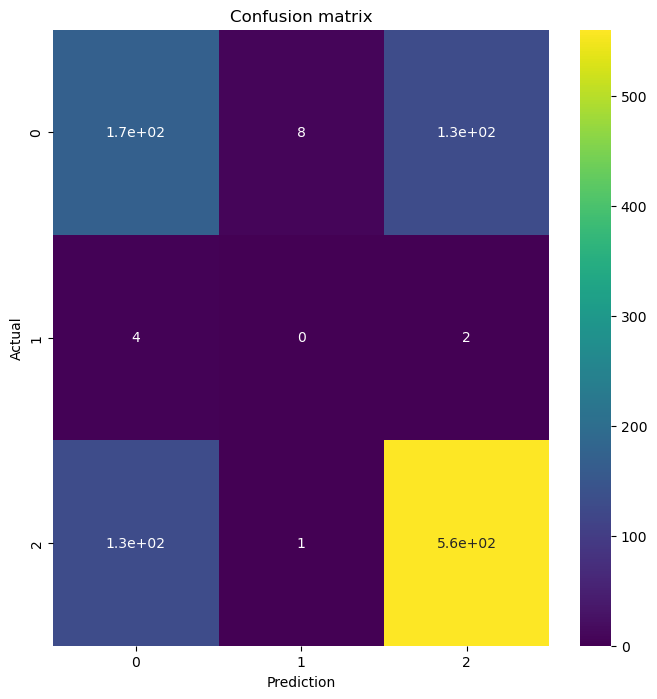

In [16]:
## Visualize a confusion matrix
plt.figure(figsize=(8,8))
sns.heatmap(conf,annot = True, cmap ="viridis")
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

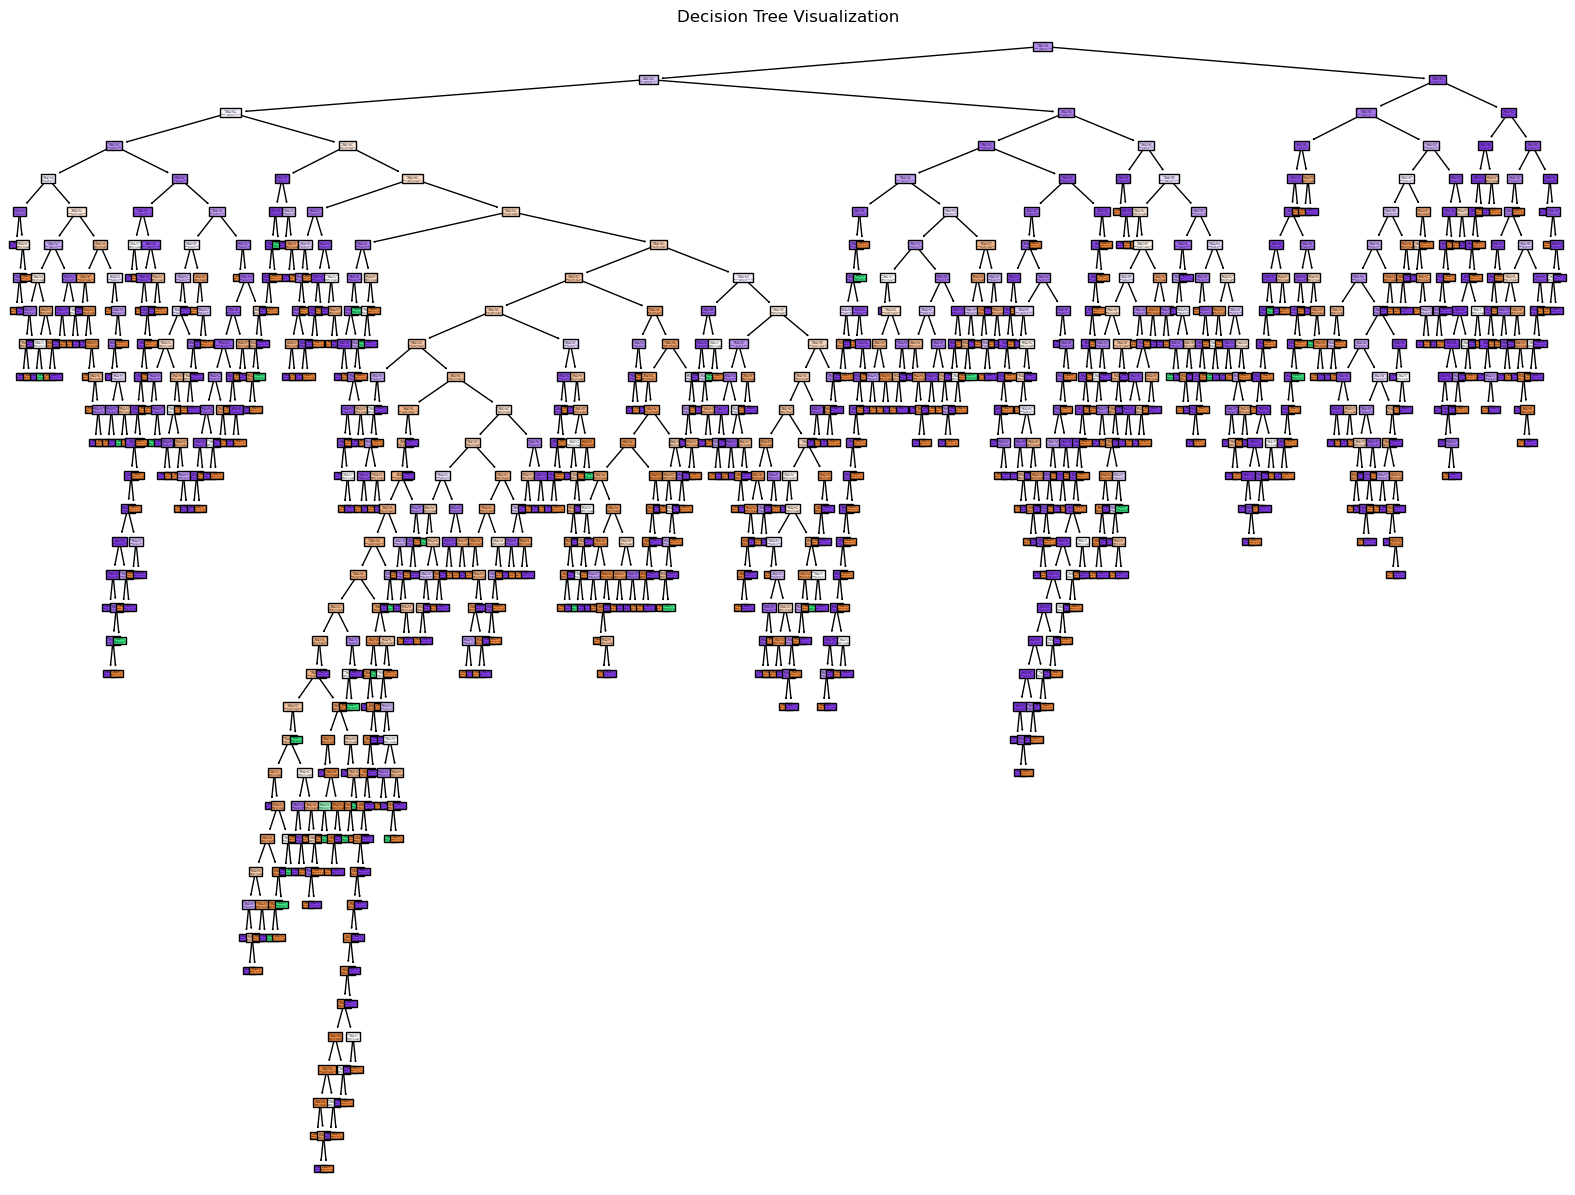

In [31]:
# extract decision tree model from pipeline
clf_dt = pipe.named_steps['model']

plt.figure(figsize=(20,15))

plot_tree(
    clf_dt,
    filled=True,
    class_names=['Average','Flop','Hit']
)

plt.title("Decision Tree Visualization")

plt.show()